# Time Data Aggregation - NDVI Example - How to request data ?

This notebook demonstrates how to interact with the Examind Coverage Service (WCS) (and OGC API Coverage) to retrieve and visualize NDVI coverage data over time. We will explore the metadata of the NDVI coverage layer and download specific time slices of the data.

## Prerequisites :

- An instance of Examind Community running somewhere
- A list of NDVI data in **Geotiff** format (*COG recommended*) somewhere *(S3 or via server file in the mount point of Examind)* **Not provided in this tutorial**
- Have a `config.json` file for the Time Series Aggregation (example [here](scripts_config/config.json)) **in the folder where the NDVI files are located**

*Example of config file*
```json
{
    "name": "ItalyCoverage",
    "watchFiles": false,
    "files": [
        {
            "path": "./SC_2006_LAEA_v2.tif",
            "startdate": "2006-01-01T00:00:00Z",
            "enddate": "2006-12-31T23:59:59Z"
        },
        {
            "path": "./SC_2012_LAEA_v2.tif",
            "startdate": "2012-01-01T00:00:00Z",
            "enddate": "2012-12-31T23:59:59Z"
        }
    ]
}
```

For this last point, you can follow the instructions in the segment below.

### Generate the config file for the Time Series Aggregation

To generate automatically the `config.json` file needed for the Time Series Aggregation, you can use the provided script [generate_config.sh](./scripts_config/generate_config.sh).

This script (written in bash that you can adapt for your needs) will take as input a file with the list of your NDVI files names ([example here](./scripts_config/file_list.txt)) and generate the `config.json` file.

In this script we assume that the files are named with the following pattern : `NDVI_AYYYYDDD_<...>.tif` where `YYYY` is the year and `DDD` is the day of the year (from 001 to 365/366). You can adapt the script to your needs if your files are named differently.

Run this command to generate the config file :
```bash
./generate_config.sh file_list.txt <path_to_save_config>/config.json
```

You can move the `config.json` file to the folder where your NDVI files are located (if not done already).

### Import data in Examind

You can follow the instructions in this pdf [here](Importing_geotiff_time_series_data_into_Examind_Community.pdf) or read the summary below.

- Go to the Examind interface in your web browser (e.g., `http://localhost:8080/examind`)
- Login with your credentials (default admin/admin)
- Go to **Data**
- Click on **Add data**
- Select your protocol and path (here **Server file** > *file:///var/examind/NDVI*)
- Wait for the files to be listed, select **LinearGridTimeSeries-examind** as the data type and **Select your config.json file**

  ![Add data ndvi](./images/img_add_data_ndvi.png)

- Click on **Next**
- Select the **NDVICoverage**

  ![viz data ndvi](./images/img_data_viz.png)

- Click on **Next**
- Create a new **Dataset** or select an existing one
- Click on **Next**
- Fill the metadata form as needed
- Click on **Finish**

#### Create a Coverage Service (WCS)
- Go to **Web Services**
- Click on **Create a service**
- Select **Coverage (WCS)**
- Fill the form (Name, Identifier), select version 1.0.0 AND 2.0.1
- Add your data to the service
- Run it

In [9]:
# Imports (Execute this cell once)
import requests
from IPython.display import display, Markdown
import json
import matplotlib.pyplot as plt
import rasterio
from io import BytesIO
import os

# Set the server ip here (before the /examind), by default: localhost:8080
SERVER_IP = "http://192.168.20.107:8080"
WCS_SERVICE_ID = "test"
LAYER_ID = "NDVICoverage"

Check if the coverage service works

In [5]:
URL = SERVER_IP + "/examind/WS/coverage/" + WCS_SERVICE_ID

r = requests.get(url = URL)

data = r.json()
data

{'links': [{'href': 'http://192.168.20.107:8080/examind/WS/coverage/test/api',
   'rel': 'service-desc',
   'type': None,
   'hreflang': None,
   'title': 'the API definition',
   'length': None},
  {'href': 'http://192.168.20.107:8080/examind/WS/coverage/test',
   'rel': 'self',
   'type': 'application/json',
   'hreflang': None,
   'title': 'this document',
   'length': None},
  {'href': 'http://192.168.20.107:8080/examind/WS/coverage/test?f=application/xml',
   'rel': 'alternate',
   'type': 'application/vnd.ogc.xml',
   'hreflang': None,
   'title': 'this document as XML',
   'length': None},
  {'href': 'http://192.168.20.107:8080/examind/WS/coverage/test/conformance',
   'rel': 'conformance',
   'type': 'application/json',
   'hreflang': None,
   'title': 'OGC API conformance classes implemented by this server as JSON',
   'length': None},
  {'href': 'http://192.168.20.107:8080/examind/WS/coverage/test/conformance?f=application/xml',
   'rel': 'conformance',
   'type': 'applicatio

### Information about the NDVI coverage layer
#### Main information

We use here the `/collections/{layerId}` endpoint to get information about the NDVI coverage layer.

In [11]:
URL = SERVER_IP + "/examind/WS/coverage/" + WCS_SERVICE_ID + "/collections/" + LAYER_ID

r = requests.get(url = URL)

data = r.json()

# Extracting data for readability
ext = data['extent']
bbox = ext['spatial']['bbox'][0]
temp = ext['temporal']['interval'][0]

md_output = f"""
## 🛰️ Coverage Metadata: `{data['id']}`

**Basic Information:**
- **Title:** {data['title']}
- **Primary CRS:** `{data['crs'][0]}`
- **Storage CRS:** `{data['storageCrs']}`

**🌍 Spatial Extent (BBOX):**
- `Min X: {bbox[0]}`
- `Min Y: {bbox[1]}`
- `Max X: {bbox[2]}`
- `Max Y: {bbox[3]}`

**📅 Temporal Extent:**
- **Start:** `{temp[0]}`
- **End:** `{temp[1]}`
"""

display(Markdown(md_output))


## 🛰️ Coverage Metadata: `NDVICoverage`

**Basic Information:**
- **Title:** NDVICoverage
- **Primary CRS:** `http://www.opengis.net/def/crs/OGC/1.3/CRS84`
- **Storage CRS:** `http://www.opengis.net/def/crs/OGC/1.3/CRS84`

**🌍 Spatial Extent (BBOX):**
- `Min X: 0.0`
- `Min Y: 29.999714120029715`
- `Max X: 31.114306120637075`
- `Max Y: 49.99999999550685`

**📅 Temporal Extent:**
- **Start:** `2001-01-03T00:51:27.737Z`
- **End:** `2017-12-29T23:08:31.262Z`


#### Domain Set information

We use here the `/collections/{layerId}/coverage/domainset` endpoint to get information about the NDVI coverage layer.

This endpoint provides details about the grid structure and dimensions of the coverage data.

In [15]:
URL = SERVER_IP + "/examind/WS/coverage/" + WCS_SERVICE_ID + "/collections/" + LAYER_ID + "/coverage/domainset"

r = requests.get(url = URL)

data = r.json()

# Data parsing
grid = data['generalGrid']
axes = grid['axis']
limits = grid['gridLimits']['axis']

# Dimension calculation (upperBound + 1 because bounds are 0-indexed)
width = limits[0]['upperBound'] + 1
height = limits[1]['upperBound'] + 1
time_steps = limits[2]['upperBound'] + 1

md_output = f"""
### 📐 Domain & Grid Specifications

**Dimensions:** {width} (W) x {height} (H) x {time_steps} (Time)

| Axis | Label | Range | Resolution |
| :--- | :--- | :--- | :--- |
| **Lon** | `{axes[0]['axisLabel']}` | `{axes[0]['lowerBound']}` to `{axes[0]['upperBound']}` | `{axes[0]['resolution']:.6f}` |
| **Lat** | `{axes[1]['axisLabel']}` | `{axes[1]['lowerBound']}` to `{axes[1]['upperBound']}` | `{axes[1]['resolution']:.6f}` |
| **Time** | `{axes[2]['axisLabel']}` | `{axes[2]['lowerBound']}` to `{axes[2]['upperBound']}` | `{axes[2]['resolution']}` |

**Grid Index Limits:**
- **i (Width):** 0 to {limits[0]['upperBound']}
- **j (Height):** 0 to {limits[1]['upperBound']}
- **k (Time):** 0 to {limits[2]['upperBound']}
"""

display(Markdown(md_output))


### 📐 Domain & Grid Specifications

**Dimensions:** 13827 (W) x 8888 (H) x 1525 (Time)

| Axis | Label | Range | Resolution |
| :--- | :--- | :--- | :--- |
| **Lon** | `lon` | `0.0` to `31.114306120637075` | `0.002250` |
| **Lat** | `lat` | `29.999714120029715` to `49.99999999550685` | `0.002250` |
| **Time** | `t` | `2001-01-03T00:51:27.737` to `2017-12-29T23:08:31.262` | `351775474.75409836` |

**Grid Index Limits:**
- **i (Width):** 0 to 13826
- **j (Height):** 0 to 8887
- **k (Time):** 0 to 1524


#### Range Type information

We use here the `/collections/{layerId}/coverage/rangetype` endpoint to get information about the NDVI coverage layer.

This endpoint provides details about the data fields and their types within the coverage data.

In [17]:
URL = SERVER_IP + "/examind/WS/coverage/" + WCS_SERVICE_ID + "/collections/" + LAYER_ID + "/coverage/rangetype"

r = requests.get(url = URL)

data = r.json()

# Extracting field info
field = data['field'][0]
field_name = field.get('name', 'N/A')
field_type = field.get('type', 'N/A')
field_desc = field.get('description', 'N/A')
data_type = field.get('encodingInfo', {}).get('dataType', 'Unknown')

md_output = f"""
### 📊 Field Definition (Data Record)

| Attribute | Details |
| :--- | :--- |
| **Field Name** | `{field_name}` |
| **Field Type** | {field_type} |
| **Description** | {field_desc} |
| **Encoding** | `{data_type}` |
"""

display(Markdown(md_output))


### 📊 Field Definition (Data Record)

| Attribute | Details |
| :--- | :--- |
| **Field Name** | `Grayscale` |
| **Field Type** | Quantity |
| **Description** | Grayscale |
| **Encoding** | `empty` |


### Download a specific time slice of the NDVI coverage

To download a specific time slice of the NDVI coverage, we use the `/collections/{layerId}/coverage` endpoint with a temporal subset parameter.

The example below requests the coverage data for the timestamp "2001-01-05T01:00:00Z". Using the `subset` parameter, we specify the desired time slice to retrieve.

**Subset Data can be :**
- axisName(80)
- axisName(80:90)
- axisName("2022-10-11T10:00:00Z":"2022-10-13T10:00:00Z")
- axisName("2022-10-11T10:00:00Z")

Status 200


IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



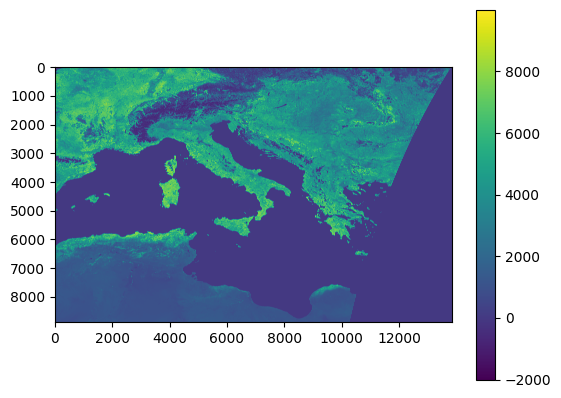

In [19]:
URL = SERVER_IP + "/examind/WS/coverage/" + WCS_SERVICE_ID + "/collections/" + LAYER_ID + "/coverage?subset=t(\"2001-01-05T01:00:00Z\")"

r = requests.get(url = URL)

print(f"Status {r.status_code}")

file_path = "./file.tiff"
os.makedirs(os.path.dirname(file_path), exist_ok=True)
with open(file_path, "wb") as f:
    f.write(r.content)

with rasterio.open(BytesIO(r.content)) as src:
    image_data = src.read()

plt.imshow(image_data.transpose([1, 2, 0]))
plt.colorbar()
plt.show()

You also can add a **spatial subset** using the `bbox` parameter to limit the data to a specific geographic area.

This bbox is defined by the coordinates: `minX,minY,maxX,maxY`.

In this case : 11.15,41.2,13.40,42.46 (`lon_min,lat_min,lon_max,lat_max`)

Status 200


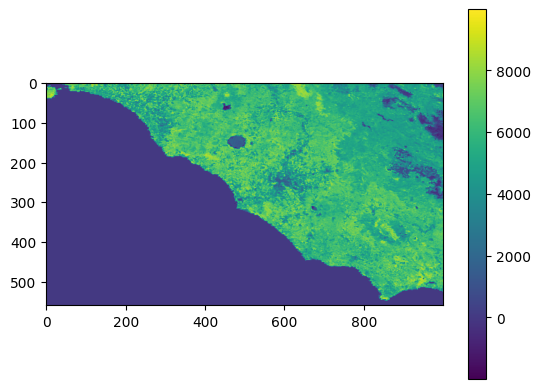

In [21]:
URL = SERVER_IP + "/examind/WS/coverage/" + WCS_SERVICE_ID + "/collections/" + LAYER_ID + "/coverage?subset=t(\"2001-01-05T01:00:00Z\")&bbox=11.15,41.2,13.40,42.46"

r = requests.get(url = URL)

print(f"Status {r.status_code}")

file_path = "./file2.tiff"
os.makedirs(os.path.dirname(file_path), exist_ok=True)
with open(file_path, "wb") as f:
    f.write(r.content)

with rasterio.open(BytesIO(r.content)) as src:
    image_data = src.read()

plt.imshow(image_data.transpose([1, 2, 0]))
plt.colorbar()
plt.show()